# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [3]:
import pandas as pd
import numpy as np
from scipy import sparse

from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import scanpy as sc

def make_pseudobulk_per_sample(adata, layer="counts"):
    """Sum all counts per sample_id."""
    if layer in adata.layers:
        X = adata.layers[layer]
    else:
        X = adata.X

    if sparse.issparse(X):
        X = X.toarray()

    sample_ids = adata.obs["sample_id"].astype(str)
    uniq_samples = sample_ids.unique()

    pb = {}
    for sid in uniq_samples:
        mask = sample_ids == sid
        pb[sid] = X[mask, :].sum(axis=0)

    counts_df = pd.DataFrame(pb, index=adata.var_names)
    meta_df = (
        adata.obs.groupby("sample_id")
        .agg({"treatment": "first"})
        .rename(columns={"treatment": "condition"})
    )

    return counts_df, meta_df

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Read data

In [24]:
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [25]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [26]:
adata = adata[adata.obs.treatment.isin(['PBS','WT'])]

## Perform pseudobulk

In [27]:
dict(zip(adata.obs['sample_id'], adata.obs['treatment']))

{'P28052_201': 'PBS',
 'P24215_101': 'WT',
 'P28052_103': 'PBS',
 'P28052_102': 'PBS',
 'P28052_301': 'PBS',
 'P28052_202': 'PBS',
 'P28052_203': 'PBS'}

In [28]:
counts_df, meta_df = make_pseudobulk_per_sample(adata, layer="counts")

## Perform DGE


In [32]:
# Convert pseudobulk to AnnData (samples x genes)
ad = AnnData(X=counts_df.T.values)
ad.var_names = counts_df.index
ad.obs_names = counts_df.columns
ad.obs = meta_df.copy()

# Build and run DESeq2
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=ad,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# Contrast BRICHOS vs WT
stat_res = DeseqStats(dds, contrast=["condition", "PBS", "WT"], inference=inference)
stat_res.summary()

# Extract results
res = stat_res.results_df
res.head()

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['P28052_201', 'P24215_101', 'P28052_103', 'P28052_102', 'P28052_301']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_80455/441290727.py:9: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encountered

Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.61 seconds.

Fitting dispersion trend curve...
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: overflow encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: invalid value encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: overflow encountered in matmul


Log2 fold change & Wald test p-value: condition PBS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            946.497650       -0.093506  0.118884 -0.786533  0.431555   
Rp1              18.252520       -0.426652  0.640919 -0.665687  0.505611   
Sox17           521.078976        0.165093  0.127679  1.293031  0.196000   
Lypla1         1682.289661       -0.188565  0.137701 -1.369382  0.170880   
Tcea1          4186.147853       -0.134175  0.095501 -1.404959  0.160034   
...                    ...             ...       ...       ...       ...   
Arhgap6         867.931355        0.318826  0.204530  1.558821  0.119039   
Hccs           2229.682946        0.006417  0.124992  0.051336  0.959058   
Mid1            339.098294        0.716721  0.515324  1.390815  0.164282   
4933400A11Rik     0.995973       -0.265029  2.209806 -0.119933  0.904536   
Asmt             10.066225       -0.570252  0.748285 -0.762078  0.446013   

                   padj  
Xkr

... done in 0.32 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Xkr4,946.497650,-0.093506,0.118884,-0.786533,0.431555,0.756466
Rp1,18.252520,-0.426652,0.640919,-0.665687,0.505611,0.807565
Sox17,521.078976,0.165093,0.127679,1.293031,0.196000,0.548363
Lypla1,1682.289661,-0.188565,0.137701,-1.369382,0.170880,0.515541
Tcea1,4186.147853,-0.134175,0.095501,-1.404959,0.160034,0.500215


In [33]:
# Top upregulated
res.sort_values("log2FoldChange", ascending=False).head(10)

# Top downregulated
res.sort_values("log2FoldChange", ascending=True).head(10)

# Significant hits
sig = res.query("padj < 0.05")
print(f"Significant DEGs: {sig.shape[0]}")

Significant DEGs: 803


In [53]:
sig = sig.sort_values(by = 'log2FoldChange',ascending = False)

In [54]:
import os

In [57]:
outdir = "../results/DGE"
os.makedirs(outdir, exist_ok=True)
sig.to_csv('../results/DGE/PBS-wt-sig.csv')
res.to_csv('../results/DGE/PBS-wt-all.csv')

In [56]:
sig.head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Cst7,2191.122062,6.853090,0.341048,20.094185,8.296496e-90,1.223484e-85
Itgax,108.917047,5.180247,0.883919,5.860548,4.613431e-09,7.559363e-07
Ccl3,176.201250,5.136483,0.669090,7.676816,1.630915e-14,5.726453e-12
Fgr,44.606099,3.462944,0.793325,4.365100,1.270646e-05,8.254718e-04
Ccl6,1145.303544,3.417958,0.175045,19.526122,6.585409e-85,4.855751e-81
Cxcl5,173.825243,2.766965,0.491220,5.632845,1.772605e-08,2.588179e-06
Cd74,2222.565484,2.551962,0.523847,4.871583,1.107077e-06,1.053295e-04
Ccl4,38.298151,2.418207,0.675200,3.581468,3.416685e-04,1.114731e-02
Pdcd1,48.841266,2.405130,0.542488,4.433520,9.270697e-06,6.388550e-04
H2-Aa,500.208778,2.264932,0.517957,4.372814,1.226550e-05,8.003513e-04


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from adjustText import adjust_text  # pip install adjustText

def volcano_pretty(
    res,
    lfc_col="log2FoldChange",
    p_col="pvalue",
    padj_col="padj",
    lfc_thr=1.0,
    padj_thr=0.05,
    top_labels=15,
    title="Volcano: BRICHOS vs WT",
    figsize=(7, 6),
):
    """Beautiful volcano plot with smart labeling."""
    df = res.copy()
    df["neglog10p"] = -np.log10(df[p_col] + 1e-300)

    # significance flags
    sig = (df[padj_col] < padj_thr) & (df[lfc_col].abs() >= lfc_thr)
    up = sig & (df[lfc_col] > 0)
    dn = sig & (df[lfc_col] < 0)
    ns = ~sig

    # size scaling by significance
    df["size"] = np.clip(df["neglog10p"] / df["neglog10p"].max() * 60, 8, 60)

    # --- Plot ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    # non-significant
    ax.scatter(
        df.loc[ns, lfc_col],
        df.loc[ns, "neglog10p"],
        s=df.loc[ns, "size"],
        c="lightgrey",
        alpha=0.5,
        lw=0,
    )

    # down
    ax.scatter(
        df.loc[dn, lfc_col],
        df.loc[dn, "neglog10p"],
        s=df.loc[dn, "size"],
        c="#4575b4",
        alpha=0.8,
        lw=0,
        label=f"down (n={dn.sum()})",
    )

    # up
    ax.scatter(
        df.loc[up, lfc_col],
        df.loc[up, "neglog10p"],
        s=df.loc[up, "size"],
        c="#d73027",
        alpha=0.8,
        lw=0,
        label=f"up (n={up.sum()})",
    )

    # threshold lines
    ax.axvline(lfc_thr, color="k", lw=0.8, ls="--")
    ax.axvline(-lfc_thr, color="k", lw=0.8, ls="--")
    ax.axhline(-np.log10(padj_thr), color="k", lw=0.8, ls="--")

    # highlight top genes
    top = df.sort_values(p_col).head(top_labels)
    texts = []
    for _, r in top.iterrows():
        gene_name = r.name if not hasattr(r, "gene") else r.get("gene", r.name)
        texts.append(
            ax.text(
                r[lfc_col],
                r["neglog10p"],
                gene_name,
                fontsize=8,
                color="black",
                ha="left",
                va="bottom",
            )
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

    # styling
    ax.set_xlabel("log2 fold change (BRICHOS vs WT)", fontsize=11)
    ax.set_ylabel("−log10(p-value)", fontsize=11)
    ax.set_title(title, fontsize=13, pad=15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

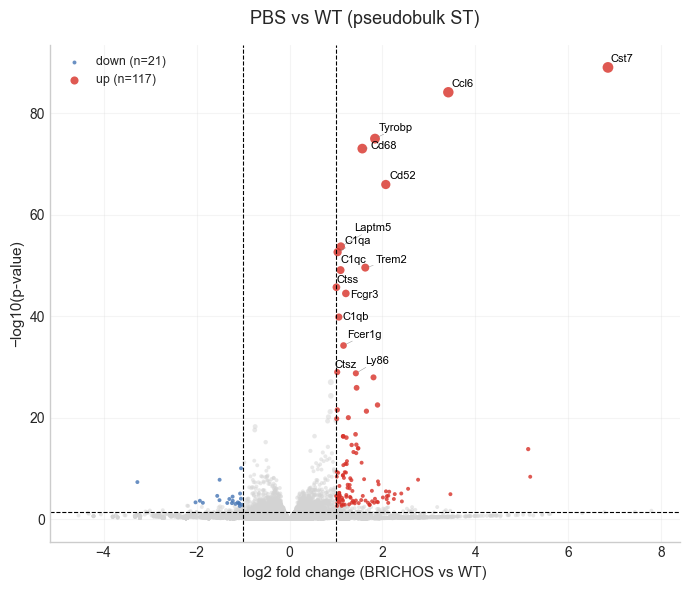

In [45]:
volcano_pretty(res, title="PBS vs WT (pseudobulk ST)")